# Raisin Detective – Random Forest Model

In this notebook, we build a Random Forest classifier to improve the baseline Decision Tree model.

Random Forest is an ensemble method that combines many decision trees. Each tree is trained on a random subset of the data and features, which makes the final model more stable and less sensitive to overfitting than a single Decision Tree.

We will train a baseline Random Forest model, evaluate its performance, use cross-validation, and then tune hyperparameters with GridSearchCV.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [3]:
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

csv_path = DATA_RAW / "raisin_dataset.csv"

df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [4]:
X = df.drop(columns="Class")
y = df["Class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
class_mapping

{'Besni': np.int64(0), 'Kecimen': np.int64(1)}

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (720, 7)
X_test shape: (180, 7)
y_train shape: (720,)
y_test shape: (180,)


## Baseline Random Forest Model

We start with a baseline Random Forest model using default settings, except for `random_state` to make the results reproducible.

This model will be compared with the previous Decision Tree baseline.

In [6]:
rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)

In [7]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Baseline Accuracy: {rf_accuracy:.4f}")

Random Forest Baseline Accuracy: 0.8667


In [8]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Besni       0.93      0.79      0.86        90
     Kecimen       0.82      0.94      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



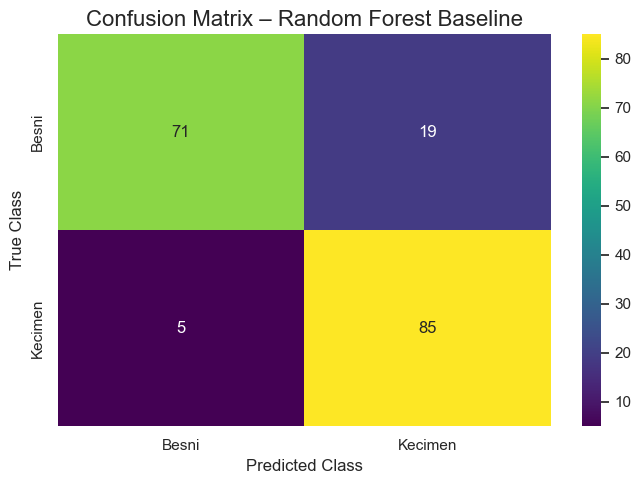

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix – Random Forest Baseline")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

In [10]:
cv_scores = cross_val_score(
    rf_baseline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

Cross-validation scores: [0.79166667 0.88194444 0.84027778 0.84722222 0.94444444]
Mean CV accuracy: 0.8611
Standard deviation: 0.0507


## Cross-Validation

Cross-validation is used to estimate how well the model generalizes to unseen data.

Instead of relying on only one train/test split, the training data is divided into several folds. The model is trained and validated multiple times, and the average score gives a more robust estimate of performance.

In [11]:
model_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest Baseline"],
    "Accuracy": [0.8444, rf_accuracy]
})

model_results

,Model,Accuracy
0,Decision Tree,0.844400
1,Random Forest Baseline,0.866667


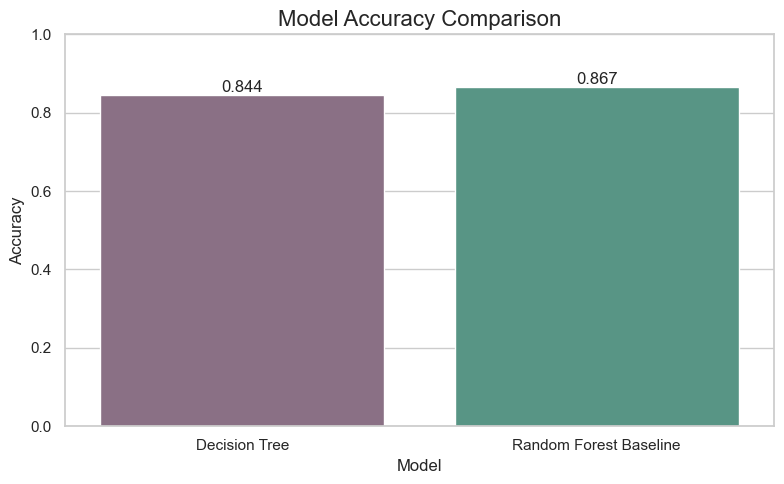

In [12]:
model_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest Baseline"],
    "Accuracy": [0.8444, rf_accuracy]
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=["#8E6C88", "#4E9F8A"],
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV

The baseline Random Forest model performed better than the single Decision Tree.  
To improve the model further, we use GridSearchCV to search for a better combination of hyperparameters.

GridSearchCV tests several parameter combinations and evaluates them using cross-validation.

In [13]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [14]:
print("Best parameters:")
print(grid_search.best_params_)

print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validation accuracy: 0.8708


In [15]:
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)

print(f"Tuned Random Forest Test Accuracy: {best_rf_accuracy:.4f}")

Tuned Random Forest Test Accuracy: 0.8722


In [16]:
print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Besni       0.95      0.79      0.86        90
     Kecimen       0.82      0.96      0.88        90

    accuracy                           0.87       180
   macro avg       0.88      0.87      0.87       180
weighted avg       0.88      0.87      0.87       180



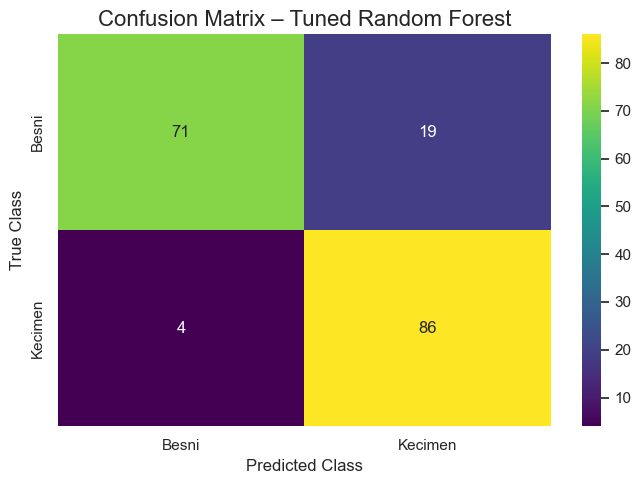

In [17]:
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix – Tuned Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

## Tuned Random Forest Result Interpretation

After hyperparameter tuning with GridSearchCV, the Random Forest model achieved a test accuracy of approximately 87%.

This is a small improvement compared to the baseline Random Forest and a clearer improvement compared to the single Decision Tree model.

The confusion matrix shows that the model performs especially well on the Kecimen class, correctly identifying 86 out of 90 Kecimen raisins. For the Besni class, the model correctly identifies 71 out of 90 raisins, but 19 Besni raisins are misclassified as Kecimen.

This means that the tuned Random Forest model is strong overall, but it still has more difficulty identifying Besni compared to Kecimen.

In [18]:
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest Baseline",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.8444,
        rf_accuracy,
        best_rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Decision Tree,0.844400
1,Random Forest Baseline,0.866667
2,Tuned Random Forest,0.872222


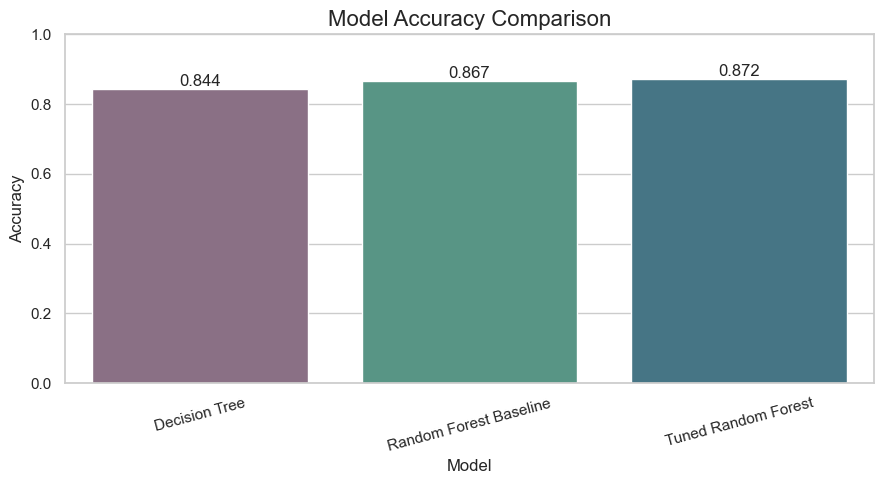

In [19]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=["#8E6C88", "#4E9F8A", "#3B7A8F"],
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()